In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
wire_path = 'wire.csv'
wu_path = 'westernunion.csv'
card_path = 'card.csv'
eft_path = 'eft.csv'
emt_path = 'emt.csv'
kyc_path = 'kyc_individual.csv'


wire = pd.read_csv(wire_path)
westernunion = pd.read_csv(wu_path)
card = pd.read_csv(card_path)
eft = pd.read_csv(eft_path)
emt = pd.read_csv(emt_path)
kyc = pd.read_csv(kyc_path)

print('✓ Loaded datasets successfully')
print(f'\nDataset sizes:')
print(f'  Wire transfers: {len(wire):,}')
print(f'  Western Union: {len(westernunion):,}')
print(f'  Card transactions: {len(card):,}')
print(f'  EFT transactions: {len(eft):,}')
print(f'  EMT transactions: {len(emt):,}')
print(f'  KYC records: {len(kyc):,}')

✓ Loaded datasets successfully

Dataset sizes:
  Wire transfers: 4,956
  Western Union: 2,142
  Card transactions: 3,553,303
  EFT transactions: 1,070,698
  EMT transactions: 845,996
  KYC records: 53,099


In [3]:
# Quick overview of each dataset
print("Wire Transfers Sample:")
print(wire.head())
print("\nKYC Data Sample:")
print(kyc.head())

Wire Transfers Sample:
     transaction_id      customer_id  amount_cad debit_credit  \
0  2411018567515752  SYNID0106350653     3070.13            C   
1  2411011617097052  SYNID0104386115      630.08            C   
2  2411017551414972  SYNID0200341758    21353.70            C   
3  2411011591775144  SYNID0107845453     1015.64            C   
4  2411015685130952  SYNID0108075156   128943.27            C   

  transaction_datetime  
0           2024-11-01  
1           2024-11-01  
2           2024-11-01  
3           2024-11-01  
4           2024-11-01  

KYC Data Sample:
       customer_id country province      city  gender marital_status  \
0  SYNID0100000167      CA       ON   TORONTO     NaN        Married   
1  SYNID0100000431      CA      NaN     other  FEMALE        Married   
2  SYNID0100000485      CA       ON  BRAMPTON  FEMALE        Widowed   
3  SYNID0100000539      CA      NaN     other    MALE        Widowed   
4  SYNID0100000932      CA       ON   TORONTO  FEMALE     

In [4]:
print(wire.columns)
print(westernunion.columns)
print(card.columns)
print(eft.columns)
print(emt.columns)

Index(['transaction_id', 'customer_id', 'amount_cad', 'debit_credit',
       'transaction_datetime'],
      dtype='object')
Index(['transaction_id', 'customer_id', 'amount_cad', 'debit_credit',
       'transaction_datetime'],
      dtype='object')
Index(['transaction_id', 'customer_id', 'amount_cad', 'debit_credit',
       'transaction_datetime', 'merchant_category', 'ecommerce_ind', 'country',
       'province', 'city'],
      dtype='object')
Index(['transaction_id', 'customer_id', 'amount_cad', 'debit_credit',
       'transaction_datetime'],
      dtype='object')
Index(['transaction_id', 'customer_id', 'amount_cad', 'debit_credit',
       'transaction_datetime'],
      dtype='object')


In [5]:
def create_transaction_features(df, prefix):
    """
    Create comprehensive features from transaction data
    """
    features = df.groupby('customer_id').agg({
    'amount_cad': ['count', 'sum', 'mean', 'std', 'min', 'max', 'median']
})  
    features.columns = [f'{prefix}_{col[1]}' for col in features.columns]
    features[f'{prefix}_coef_variation'] = features[f'{prefix}_std'] / (features[f'{prefix}_mean'] + 1e-6)
    features[f'{prefix}_range'] = features[f'{prefix}_max'] - features[f'{prefix}_min']
    features[f'{prefix}_mean_to_max_ratio'] = features[f'{prefix}_mean'] / (features[f'{prefix}_max'] + 1e-6)
    features[f'{prefix}_std'] = features[f'{prefix}_std'].fillna(0)
    features[f'{prefix}_coef_variation'] = features[f'{prefix}_coef_variation'].fillna(0)
    return features

wire_features = create_transaction_features(wire, 'wire')
wu_features = create_transaction_features(westernunion, 'wu')
card_features = create_transaction_features(card, 'card')
eft_features = create_transaction_features(eft, 'eft')
emt_features = create_transaction_features(emt, 'emt')

In [6]:
all_customers = set()
for df in [wire, westernunion, card, eft, emt]:
    all_customers.update(df['customer_id'].unique())

features = pd.DataFrame({'customer_id': list(all_customers)})
features = features.merge(wire_features, on='customer_id', how='left')
features = features.merge(wu_features, on='customer_id', how='left')
features = features.merge(card_features, on='customer_id', how='left')
features = features.merge(eft_features, on='customer_id', how='left')
features = features.merge(emt_features, on='customer_id', how='left')

features = features.fillna(0)

### 3.1 Advanced Feature Engineering

In [7]:
count_cols = [col for col in features.columns if '_count' in col]
sum_cols = [col for col in features.columns if '_sum' in col]
mean_cols = [col for col in features.columns if '_mean' in col and '_to_' not in col]

features['total_transactions'] = features[count_cols].sum(axis=1)
features['total_amount'] = features[sum_cols].sum(axis=1)
features['avg_transaction_amount'] = features['total_amount'] / (features['total_transactions'] + 1e-6)

features['channel_diversity'] = (features[count_cols] > 0).sum(axis=1)

transaction_shares = features[count_cols].div(features['total_transactions'] + 1e-6, axis=0)
features['channel_concentration'] = (transaction_shares ** 2).sum(axis=1)

amount_shares = features[sum_cols].div(features['total_amount'] + 1e-6, axis=0)
features['amount_concentration'] = (amount_shares ** 2).sum(axis=1)

In [8]:
features['wire_preference'] = features['wire_sum'] / (features['total_amount'] + 1e-6)
features['wu_preference'] = features['wu_sum'] / (features['total_amount'] + 1e-6)
features['card_preference'] = features['card_sum'] / (features['total_amount'] + 1e-6)
features['eft_preference'] = features['eft_sum'] / (features['total_amount'] + 1e-6)
features['emt_preference'] = features['emt_sum'] / (features['total_amount'] + 1e-6)

max_cols = [col for col in features.columns if '_max' in col and 'ratio' not in col]
features['max_single_transaction'] = features[max_cols].max(axis=1)
features['max_to_avg_ratio'] = features['max_single_transaction'] / (features['avg_transaction_amount'] + 1e-6)

std_cols = [col for col in features.columns if '_std' in col and 'to_' not in col]
features['overall_std'] = features[std_cols].mean(axis=1)
features['consistency_score'] = 1 / (features['overall_std'] + 1)

In [9]:
kyc['birth_date'] = pd.to_datetime(kyc['birth_date'], errors='coerce')
kyc['age'] = (pd.Timestamp.today() - kyc['birth_date']).dt.days // 365
kyc = kyc.rename(columns={'occupation_code': 'occupation'})

In [10]:
features = features.merge(kyc[['customer_id', 'income', 'age', 'occupation']], 
                         on='customer_id', how='left')

features['amount_to_income_ratio'] = features['total_amount'] / (features['income'] + 1e-6)
features['transactions_to_income_ratio'] = features['total_transactions'] / (features['income'] + 1e-6)
features['avg_transaction_to_income'] = features['avg_transaction_amount'] / (features['income'] + 1e-6)

features['amount_per_age'] = features['total_amount'] / (features['age'] + 1e-6)
features['transactions_per_age'] = features['total_transactions'] / (features['age'] + 1e-6)

occupation_dummies = pd.get_dummies(features['occupation'], prefix='occ')
features = pd.concat([features, occupation_dummies], axis=1)

features['income'] = features['income'].fillna(features['income'].median())
features['age'] = features['age'].fillna(features['age'].median())


In [11]:
features['large_transaction_flag'] = (features['max_to_avg_ratio'] > 10).astype(int)

features['high_wire_usage'] = (features['wire_preference'] > 0.5).astype(int)

features['unusual_income_ratio'] = (features['amount_to_income_ratio'] > 2).astype(int)

features['single_channel_user'] = (features['channel_diversity'] == 1).astype(int)

volume_threshold = features['total_transactions'].quantile(0.95)
features['high_volume_flag'] = (features['total_transactions'] > volume_threshold).astype(int)

amount_threshold = features['total_amount'].quantile(0.95)
features['high_amount_flag'] = (features['total_amount'] > amount_threshold).astype(int)

In [12]:
features.head()

,customer_id,wire_count,wire_sum,wire_mean,wire_std,wire_min,wire_max,wire_median,wire_coef_variation,wire_range,...,occ_RETIRED,occ_SELF_EMPLOYED,occ_STUDENT,occ_UNEMPLOYED,large_transaction_flag,high_wire_usage,unusual_income_ratio,single_channel_user,high_volume_flag,high_amount_flag
0,SYNID0108119055,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,True,False,False,1,0,0,0,0,0
1,SYNID0105224659,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,1,0,0,0,0,0
2,SYNID0101862070,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,1,0,1,0,0,0
3,SYNID0109180721,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,0,0,0,1,0,0
4,SYNID0103599830,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,True,False,False,False,1,0,0,0,0,0


## 4. Data Preprocessing for Model Training

In [13]:
feature_cols = [col for col in features.columns if col not in ['customer_id', 'occupation']]
X = features[feature_cols].copy()

print(f"Features for modeling: {X.shape[1]}")
print(f"Customers: {X.shape[0]:,}")

print(f"\nMissing values: {X.isnull().sum().sum()}")
print(f"Infinite values: {np.isinf(X).sum().sum()}")

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())


Features for modeling: 180
Customers: 60,318

Missing values: 88839
Infinite values: 0


In [14]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
print(X_scaled.describe())

         wire_count      wire_sum     wire_mean      wire_std      wire_min  \
count  60318.000000  6.031800e+04  6.031800e+04  6.031800e+04  6.031800e+04   
mean       0.082165  3.665138e+03  1.431843e+03  8.000582e+02  9.654640e+02   
std        2.074019  1.277227e+05  9.029274e+04  2.556354e+04  8.921454e+04   
min        0.000000  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
25%        0.000000  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
50%        0.000000  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
75%        0.000000  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
max      467.000000  2.051811e+07  2.051811e+07  3.652623e+06  2.051811e+07   

           wire_max   wire_median  wire_coef_variation    wire_range  \
count  6.031800e+04  6.031800e+04         60318.000000  6.031800e+04   
mean   2.885050e+03  1.174614e+03             0.015431  1.919586e+03   
std    1.123837e+05  8.951501e+04             0.145542  6.827221e+04   


## 5. Isolation Forest Training

Isolation Forest works by:
1. Randomly selecting features and split values
2. Creating isolation trees
3. Anomalies are isolated earlier (shorter path length)
4. Anomaly score based on average path length across trees

In [15]:
iso_forest = IsolationForest(
    n_estimators=200,          
    max_samples='auto',         
    contamination=0.05,         
    max_features=1.0,          
    random_state=42,
    n_jobs=-1,                
    verbose=1
)

iso_forest.fit(X_scaled)

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   2 out of  12 | elapsed:    0.4s remaining:    2.2s
[Parallel(n_jobs=12)]: Done  12 out of  12 | elapsed:    0.4s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.4s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:    0.4s finished


IsolationForest(contamination=0.05, n_estimators=200, n_jobs=-1,
                random_state=42, verbose=1)

In [16]:
predictions = iso_forest.predict(X_scaled)

anomaly_scores = iso_forest.score_samples(X_scaled)

features['anomaly_prediction'] = predictions
features['anomaly_score'] = anomaly_scores
features['is_anomaly'] = (predictions == -1).astype(int)

print(f"\nAnomaly Detection Results:")
print(f"Normal customers: {(predictions == 1).sum():,} ({(predictions == 1).sum()/len(predictions)*100:.2f}%)")
print(f"Anomalous customers: {(predictions == -1).sum():,} ({(predictions == -1).sum()/len(predictions)*100:.2f}%)")

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:    0.3s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s



Anomaly Detection Results:
Normal customers: 57,302 (95.00%)
Anomalous customers: 3,016 (5.00%)


[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:    0.3s finished


## 6. Model Evaluation and Analysis

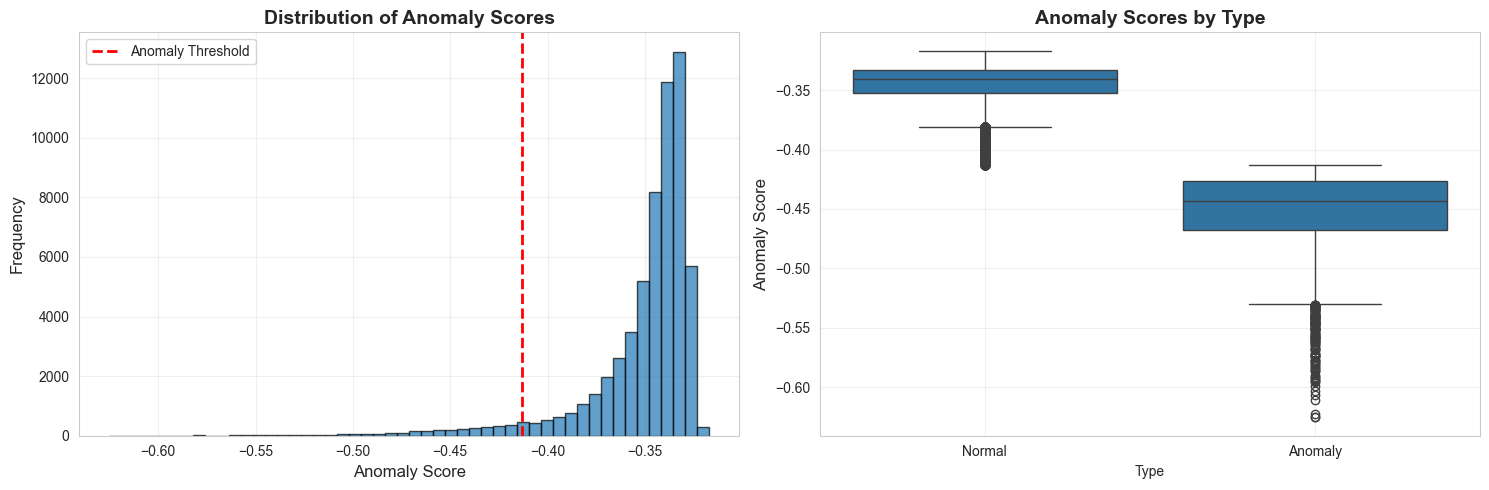


Anomaly Score Statistics:
Mean: -0.3509
Std: 0.0300
Min: -0.6252
Max: -0.3169


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(anomaly_scores, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(x=anomaly_scores[predictions == -1].max(), 
                color='red', linestyle='--', linewidth=2, label='Anomaly Threshold')
axes[0].set_xlabel('Anomaly Score', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Anomaly Scores', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

score_data = pd.DataFrame({
    'Score': anomaly_scores,
    'Type': ['Anomaly' if p == -1 else 'Normal' for p in predictions]
})
sns.boxplot(data=score_data, x='Type', y='Score', ax=axes[1])
axes[1].set_title('Anomaly Scores by Type', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Anomaly Score', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nAnomaly Score Statistics:")
print(f"Mean: {anomaly_scores.mean():.4f}")
print(f"Std: {anomaly_scores.std():.4f}")
print(f"Min: {anomaly_scores.min():.4f}")
print(f"Max: {anomaly_scores.max():.4f}")

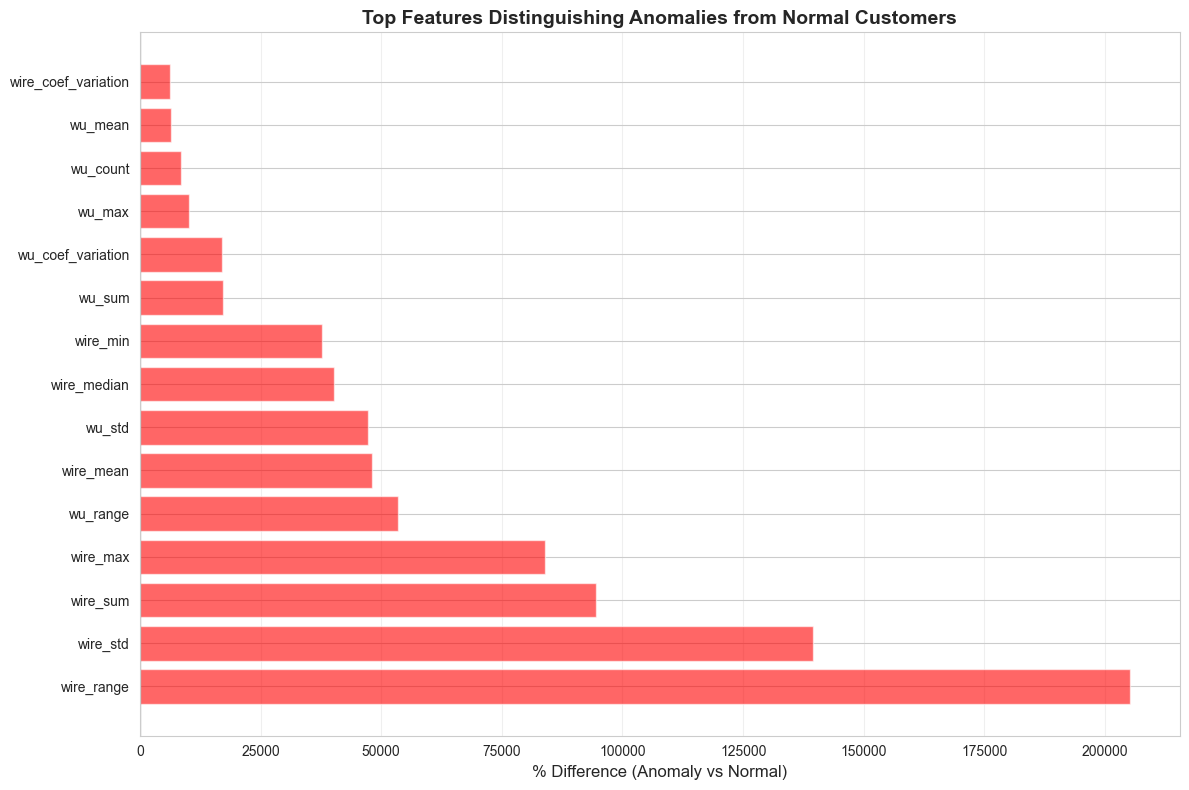

In [18]:
anomalies = features[features['is_anomaly'] == 1]
normal = features[features['is_anomaly'] == 0]

numeric_features = X.columns[:20]

feature_differences = []
for col in numeric_features:
    anom_mean = anomalies[col].mean()
    norm_mean = normal[col].mean()
    diff_pct = ((anom_mean - norm_mean) / (norm_mean + 1e-6)) * 100
    feature_differences.append({
        'feature': col,
        'anomaly_mean': anom_mean,
        'normal_mean': norm_mean,
        'diff_pct': diff_pct
    })


diff_df = pd.DataFrame(feature_differences)
diff_df = diff_df.sort_values('diff_pct', key=abs, ascending=False)


plt.figure(figsize=(12, 8))
top_features = diff_df.head(15)
colors = ['red' if x > 0 else 'blue' for x in top_features['diff_pct']]
plt.barh(range(len(top_features)), top_features['diff_pct'], color=colors, alpha=0.6)
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('% Difference (Anomaly vs Normal)', fontsize=12)
plt.title('Top Features Distinguishing Anomalies from Normal Customers', 
          fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

In [19]:
print("="*80)
print("ANOMALOUS CUSTOMER CHARACTERISTICS")
print("="*80)

comparison_features = [
    'total_transactions', 'total_amount', 'avg_transaction_amount',
    'channel_diversity', 'amount_to_income_ratio', 'max_to_avg_ratio',
    'wire_preference', 'channel_concentration'
]

comparison_df = pd.DataFrame({
    'Feature': comparison_features,
    'Anomaly Mean': [anomalies[f].mean() for f in comparison_features],
    'Normal Mean': [normal[f].mean() for f in comparison_features],
    'Anomaly Median': [anomalies[f].median() for f in comparison_features],
    'Normal Median': [normal[f].median() for f in comparison_features]
})

comparison_df['Mean Ratio'] = comparison_df['Anomaly Mean'] / (comparison_df['Normal Mean'] + 1e-6)
print("\n", comparison_df.to_string(index=False))
print("\n" + "="*80)
print("RISK FLAG DISTRIBUTION")
print("="*80)


risk_flags = ['large_transaction_flag', 'high_wire_usage', 'unusual_income_ratio',
              'single_channel_user', 'high_volume_flag', 'high_amount_flag']


for flag in risk_flags:
    anom_pct = anomalies[flag].mean() * 100
    norm_pct = normal[flag].mean() * 100
    print(f"{flag:30s}: Anomaly={anom_pct:5.1f}%  Normal={norm_pct:5.1f}%")

ANOMALOUS CUSTOMER CHARACTERISTICS

                Feature  Anomaly Mean  Normal Mean  Anomaly Median  Normal Median  Mean Ratio
    total_transactions    174.381300    86.404680      111.000000      56.000000    2.018193
          total_amount 373040.351386 26057.925253   112089.365000   17879.490000   14.315812
avg_transaction_amount   6868.589675   492.276323     1091.719182     295.571361   13.952712
     channel_diversity      2.906499     2.384018        3.000000       3.000000    1.219159
amount_to_income_ratio   2101.524688   263.322095        3.222408       0.527797    7.980814
      max_to_avg_ratio     67.506619    14.887079       37.662515      10.449038    4.534578
       wire_preference      0.218949     0.003825        0.000000       0.000000   57.230926
 channel_concentration      0.682261     0.682995        0.681884       0.651121    0.998924

RISK FLAG DISTRIBUTION
large_transaction_flag        : Anomaly= 83.4%  Normal= 52.1%
high_wire_usage               : Anomaly=

Performing PCA for visualization...


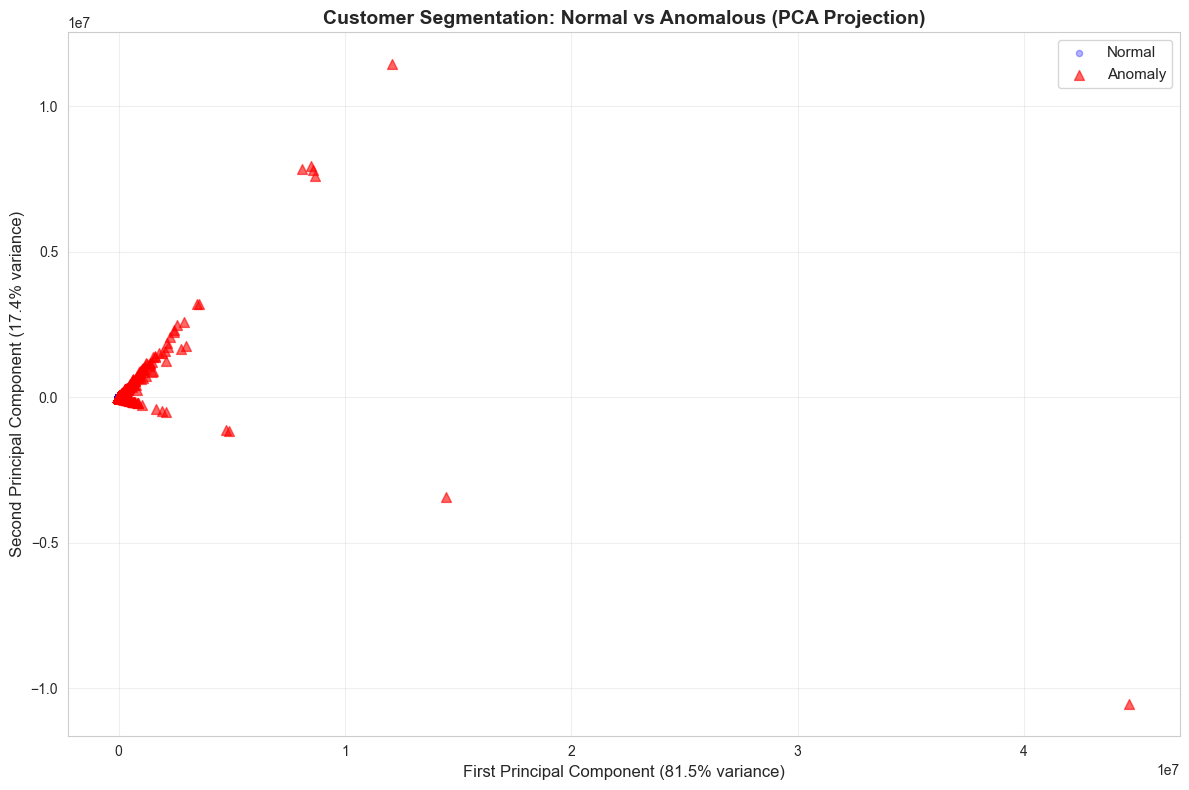


Total variance explained by 2 components: 98.9%


In [20]:
print("Performing PCA for visualization...")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[predictions == 1, 0], X_pca[predictions == 1, 1],
                     c='blue', alpha=0.3, s=20, label='Normal')
scatter = plt.scatter(X_pca[predictions == -1, 0], X_pca[predictions == -1, 1],
                     c='red', alpha=0.6, s=50, marker='^', label='Anomaly')
plt.xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]:.1%} variance)', 
           fontsize=12)
plt.ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]:.1%} variance)', 
           fontsize=12)
plt.title('Customer Segmentation: Normal vs Anomalous (PCA Projection)', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nTotal variance explained by 2 components: {pca.explained_variance_ratio_.sum():.1%}")

## 7. Top Anomalous Customers Analysis

TOP 20 MOST ANOMALOUS CUSTOMERS
    customer_id  anomaly_score  total_transactions  total_amount  channel_diversity  amount_to_income_ratio  wire_preference  max_to_avg_ratio   income  age
SYNID0200071039      -0.625243                76.0    1159613.35                  4                     NaN         0.717259         48.147260  36013.0 47.0
SYNID0105411519      -0.624784               311.0     331204.42                  5                     NaN         0.621611        192.148711  36013.0 27.0
SYNID0200837172      -0.622590               721.0    2725678.68                  4                     NaN         0.312465        171.699265  36013.0 47.0
SYNID0200388599      -0.610526               315.0    3495980.91                  3                     NaN         0.292230        153.174902  36013.0 47.0
SYNID0200017800      -0.606176               630.0    2328565.00                  3                     NaN         0.709403        266.614380  36013.0 47.0
SYNID0200263267      -0.60

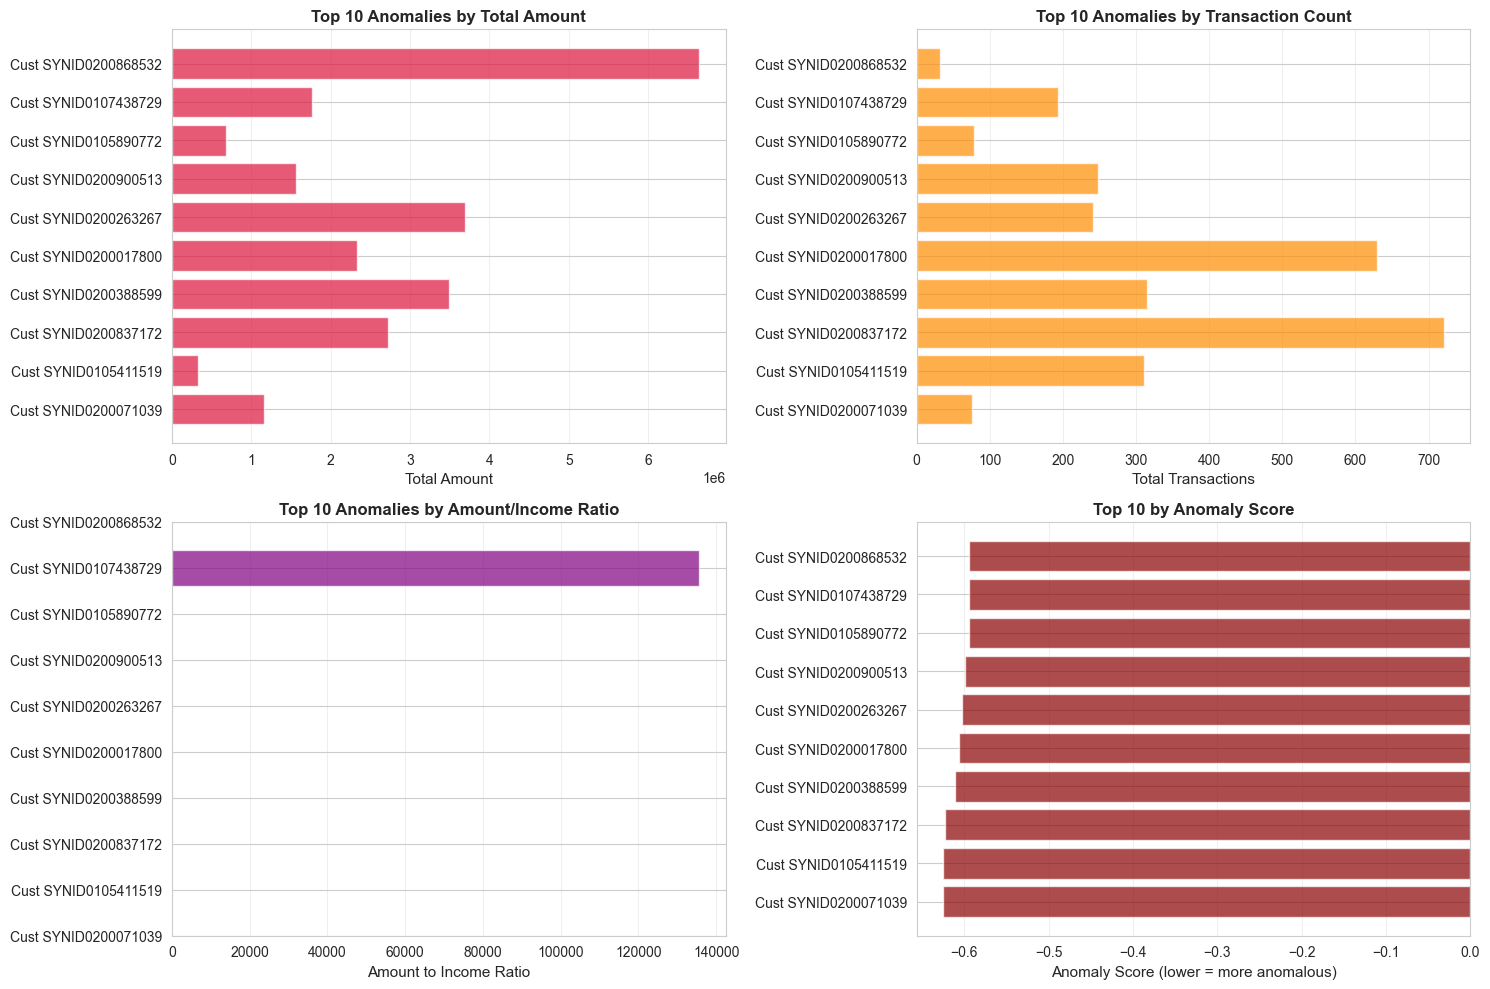

In [ ]:
top_anomalies = features.nsmallest(20, 'anomaly_score')[[
    'customer_id', 'anomaly_score', 'total_transactions', 'total_amount',
    'channel_diversity', 'amount_to_income_ratio', 'wire_preference',
    'max_to_avg_ratio', 'income', 'age'
]]

print("="*120)
print("TOP 20 MOST ANOMALOUS CUSTOMERS")
print("="*120)
print(top_anomalies.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].barh(range(10), top_anomalies.head(10)['total_amount'], color='crimson', alpha=0.7)
axes[0, 0].set_yticks(range(10))
axes[0, 0].set_yticklabels([f"Cust {id}" for id in top_anomalies.head(10)['customer_id']])
axes[0, 0].set_xlabel('Total Amount', fontsize=11)
axes[0, 0].set_title('Top 10 Anomalies by Total Amount', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='x')


axes[0, 1].barh(range(10), top_anomalies.head(10)['total_transactions'], color='darkorange', alpha=0.7)
axes[0, 1].set_yticks(range(10))
axes[0, 1].set_yticklabels([f"Cust {id}" for id in top_anomalies.head(10)['customer_id']])
axes[0, 1].set_xlabel('Total Transactions', fontsize=11)
axes[0, 1].set_title('Top 10 Anomalies by Transaction Count', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='x')


axes[1, 0].barh(range(10), top_anomalies.head(10)['amount_to_income_ratio'], color='purple', alpha=0.7)
axes[1, 0].set_yticks(range(10))
axes[1, 0].set_yticklabels([f"Cust {id}" for id in top_anomalies.head(10)['customer_id']])
axes[1, 0].set_xlabel('Amount to Income Ratio', fontsize=11)
axes[1, 0].set_title('Top 10 Anomalies by Amount/Income Ratio', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='x')


axes[1, 1].barh(range(10), top_anomalies.head(10)['anomaly_score'], color='darkred', alpha=0.7)
axes[1, 1].set_yticks(range(10))
axes[1, 1].set_yticklabels([f"Cust {id}" for id in top_anomalies.head(10)['customer_id']])
axes[1, 1].set_xlabel('Anomaly Score (lower = more anomalous)', fontsize=11)
axes[1, 1].set_title('Top 10 by Anomaly Score', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 8. Save Results

In [22]:
output_path = 'isolation_forest_results.csv'
features.to_csv(output_path, index=False)
print(f"✓ Complete results saved to: {output_path}")

anomaly_path = 'detected_anomalies.csv'
anomalies.to_csv(anomaly_path, index=False)
print(f"✓ Anomalous customers saved to: {anomaly_path}")

summary = {
    'Total Customers': len(features),
    'Normal Customers': (predictions == 1).sum(),
    'Anomalous Customers': (predictions == -1).sum(),
    'Anomaly Rate': f"{(predictions == -1).sum()/len(predictions)*100:.2f}%",
    'Features Used': len(feature_cols),
    'Mean Anomaly Score': f"{anomaly_scores.mean():.4f}",
    'Contamination Rate': '5%'
}

summary_df = pd.DataFrame([summary]).T
summary_df.columns = ['Value']
summary_df.to_csv('model_summary.csv')
print(f"✓ Model summary saved to: model_summary.csv")
print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)
print("\nSummary:")
for key, value in summary.items():
    print(f"  {key}: {value}")

✓ Complete results saved to: isolation_forest_results.csv
✓ Anomalous customers saved to: detected_anomalies.csv
✓ Model summary saved to: model_summary.csv

ANALYSIS COMPLETE

Summary:
  Total Customers: 60318
  Normal Customers: 57302
  Anomalous Customers: 3016
  Anomaly Rate: 5.00%
  Features Used: 180
  Mean Anomaly Score: -0.3509
  Contamination Rate: 5%
